In [2]:
import pandas as pd
import numpy as np

In [3]:
mar = pd.read_csv("mcu.csv")
mar

,movie_title,mcu_phase,release_date,tomato_meter,audience_score,movie_duration,production_budget,opening_weekend,domestic_box_office,worldwide_box_office
0,Iron Man,Phase 1,2008-05-02,94,91,126.0,140000000.0,102118668.0,319034126.0,585796247.0
1,The Incredible Hulk,Phase 1,2008-06-13,67,70,112.0,137500000.0,55414050.0,134806913.0,265573859.0
2,Iron Man 2,Phase 1,2010-05-07,72,71,124.0,200000000.0,128122480.0,312433331.0,621156389.0
3,Thor,Phase 1,2011-05-06,77,76,114.0,150000000.0,65723338.0,181030624.0,449326618.0
4,Captain America The First Avenger,Phase 1,2011-07-22,80,75,124.0,140000000.0,65058524.0,176654505.0,370569774.0
...,...,...,...,...,...,...,...,...,...,...
57,Wonder Man,Phase 6,2026-01-27,91,82,NaN,NaN,NaN,NaN,NaN
58,Your Friendly Neighborhood Spider-Man Season 2,Phase 6,2026-09-01,95,65,NaN,NaN,NaN,NaN,NaN
59,Daredevil Born Again Season 2,Phase 6,2026-03-24,90,89,NaN,NaN,NaN,NaN,NaN
60,The Punisher One Last Kill,Phase 6,2026-05-12,87,90,NaN,NaN,NaN,NaN,NaN


In [4]:
mar = mar.dropna()
mar

,movie_title,mcu_phase,release_date,tomato_meter,audience_score,movie_duration,production_budget,opening_weekend,domestic_box_office,worldwide_box_office
0,Iron Man,Phase 1,2008-05-02,94,91,126.0,140000000.0,102118668.0,319034126.0,5.857962e+08
1,The Incredible Hulk,Phase 1,2008-06-13,67,70,112.0,137500000.0,55414050.0,134806913.0,2.655739e+08
2,Iron Man 2,Phase 1,2010-05-07,72,71,124.0,200000000.0,128122480.0,312433331.0,6.211564e+08
3,Thor,Phase 1,2011-05-06,77,76,114.0,150000000.0,65723338.0,181030624.0,4.493266e+08
4,Captain America The First Avenger,Phase 1,2011-07-22,80,75,124.0,140000000.0,65058524.0,176654505.0,3.705698e+08
5,The Avengers,Phase 1,2012-05-04,91,91,143.0,220000000.0,207438708.0,623357910.0,1.518813e+09
6,Iron Man 3,Phase 2,2013-05-03,79,78,130.0,200000000.0,174144585.0,409013994.0,1.214811e+09
7,Thor The Dark World,Phase 2,2013-11-08,66,75,112.0,170000000.0,85737841.0,206362140.0,6.446025e+08
8,Captain America The Winter Soldier,Phase 2,2014-04-04,90,92,136.0,170000000.0,95023721.0,259766572.0,7.144215e+08
9,Guardians of the Galaxy,Phase 2,2014-08-01,91,92,121.0,170000000.0,94307658.0,333176600.0,7.733501e+08


In [5]:
money = mar.groupby(["mcu_phase"])[["production_budget","domestic_box_office","worldwide_box_office"]].mean()
money

,production_budget,domestic_box_office,worldwide_box_office
mcu_phase,,,
Phase 1,1.645833e+08,2.912196e+08,6.352060e+08
Phase 2,2.008333e+08,3.079212e+08,8.769691e+08
Phase 3,2.134545e+08,4.501295e+08,1.229760e+09
Phase 4,2.122857e+08,3.694680e+08,8.160761e+08
Phase 5,2.133333e+08,2.809202e+08,6.105627e+08
Phase 6,2.125000e+08,5.663434e+08,1.373187e+09


In [6]:
def my_format(x):
    return f"${x:,.2f}"
money_format = money.applymap(my_format)  #.applymap applies to every cell
money_format

C:\Users\Invate\AppData\Local\Temp\ipykernel_8008\3817070747.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  money_format = money.applymap(my_format)  #.applymap applies to every cell


,production_budget,domestic_box_office,worldwide_box_office
mcu_phase,,,
Phase 1,"$164,583,333.33","$291,219,568.17","$635,205,979.17"
Phase 2,"$200,833,333.33","$307,921,222.83","$876,969,060.33"
Phase 3,"$213,454,545.45","$450,129,501.00","$1,229,759,662.55"
Phase 4,"$212,285,714.29","$369,468,022.14","$816,076,133.29"
Phase 5,"$213,333,333.33","$280,920,189.00","$610,562,653.50"
Phase 6,"$212,500,000.00","$566,343,393.50","$1,373,187,120.50"


In [7]:
def profit(x):
    return (x[1] + x[2]) - x[0]

money["profit"] = money.apply(profit, axis=1)
money["profit_fmt"] = money["profit"].apply(lambda x: f"${x:,.2f}")
money["profit_fmt"]



C:\Users\Invate\AppData\Local\Temp\ipykernel_8008\3935533999.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (x[1] + x[2]) - x[0]


mcu_phase
Phase 1      $761,842,214.00
Phase 2      $984,056,949.83
Phase 3    $1,466,434,618.09
Phase 4      $973,258,441.14
Phase 5      $678,149,509.17
Phase 6    $1,727,030,514.00
Name: profit_fmt, dtype: object

In [8]:
rating = mar.groupby(["mcu_phase"])[["tomato_meter","audience_score"]].mean()
rating 

,tomato_meter,audience_score
mcu_phase,,
Phase 1,80.166667,79.000000
Phase 2,80.833333,84.000000
Phase 3,89.181818,83.272727
Phase 4,75.857143,88.428571
Phase 5,67.166667,86.500000
Phase 6,87.500000,91.500000


In [9]:
rating.applymap(lambda x: f"{x:.2f}")


C:\Users\Invate\AppData\Local\Temp\ipykernel_8008\4096707708.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  rating.applymap(lambda x: f"{x:.2f}")


,tomato_meter,audience_score
mcu_phase,,
Phase 1,80.17,79.00
Phase 2,80.83,84.00
Phase 3,89.18,83.27
Phase 4,75.86,88.43
Phase 5,67.17,86.50
Phase 6,87.50,91.50


In [10]:
rate = rating["tomato_meter"] - rating["audience_score"]
rate

mcu_phase
Phase 1     1.166667
Phase 2    -3.166667
Phase 3     5.909091
Phase 4   -12.571429
Phase 5   -19.333333
Phase 6    -4.000000
dtype: float64

In [11]:
mar_rating = mar.groupby(["movie_title"])[["tomato_meter","audience_score"]].mean()
mar_rating_diff = mar_rating["tomato_meter"] - mar_rating["audience_score"]  #the bigger the difference the less popular it was with the audience
mar_rating_diff = mar_rating_diff.sort_values(ascending=False)

In [12]:
df = pd.DataFrame({
        "rating": mar_rating_diff
})
df

,rating
movie_title,
Captain Marvel,34.0
Black Panther,17.0
Ant-Man and the Wasp,7.0
Thor Ragnarok,6.0
Captain America The First Avenger,5.0
Spider-Man Homecoming,5.0
Avengers Endgame,4.0
Doctor Strange,3.0
Iron Man,3.0


In [ ]:
total_box_office = mar["domestic_box_office"] + mar["worldwide_box_office"]
total_box_office_fmt = total_box_office.apply(lambda x: f"${x:,.2f}")
mar["total_box_office"] = total_box_office_fmt
mar.groupby(["movie_title","movie_duration"])[["total_box_office"]].sum()




C:\Users\Invate\AppData\Local\Temp\ipykernel_8008\3131687173.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mar["total_box_office"] = total_box_office_fmt


,,total_box_office
movie_title,movie_duration,
Ant-Man,117.0,"$699,514,128.00"
Ant-Man and the Wasp,118.0,"$839,322,879.00"
Ant-Man and the Wasp Quantumania,125.0,"$690,576,089.00"
Avengers Age of Ultron,141.0,"$1,854,322,847.00"
Avengers Endgame,181.0,"$3,657,812,100.00"
Avengers Infinity War,149.0,"$2,731,230,521.00"
Black Panther,134.0,"$2,053,709,010.00"
Black Panther Wakanda Forever,161.0,"$1,313,037,896.00"
Black Widow,134.0,"$563,403,310.00"


C:\Users\Invate\AppData\Local\Temp\ipykernel_8008\2707801749.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mar["total_box_office"] = total_box_office        # numeric
C:\Users\Invate\AppData\Local\Temp\ipykernel_8008\2707801749.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mar["total_box_office_fmt"] = total_box_office_fmt   # formatted


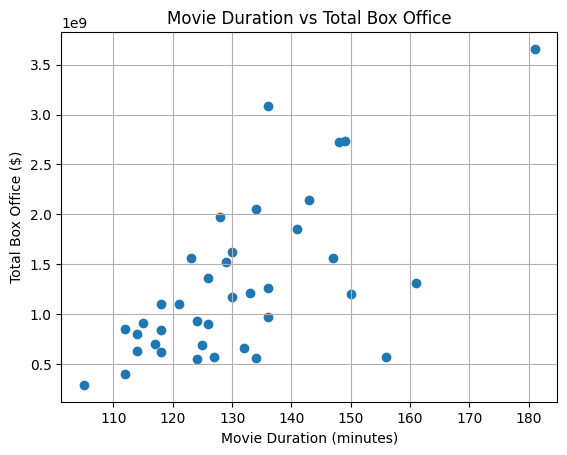

In [14]:
mar["total_box_office"] = total_box_office        # numeric
mar["total_box_office_fmt"] = total_box_office_fmt   # formatted

plt.scatter(mar["movie_duration"], mar["total_box_office"])
plt.xlabel("Movie Duration (minutes)")
plt.ylabel("Total Box Office ($)")
plt.title("Movie Duration vs Total Box Office")
plt.grid(True)
plt.show()


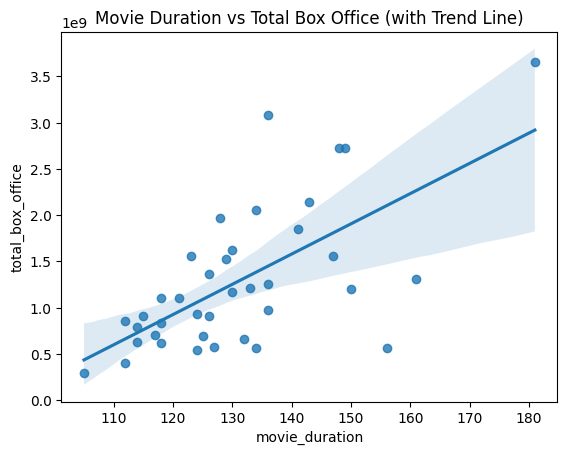

In [15]:
import seaborn as sns

sns.regplot(x="movie_duration", y="total_box_office", data=mar)
plt.title("Movie Duration vs Total Box Office (with Trend Line)")
plt.show()

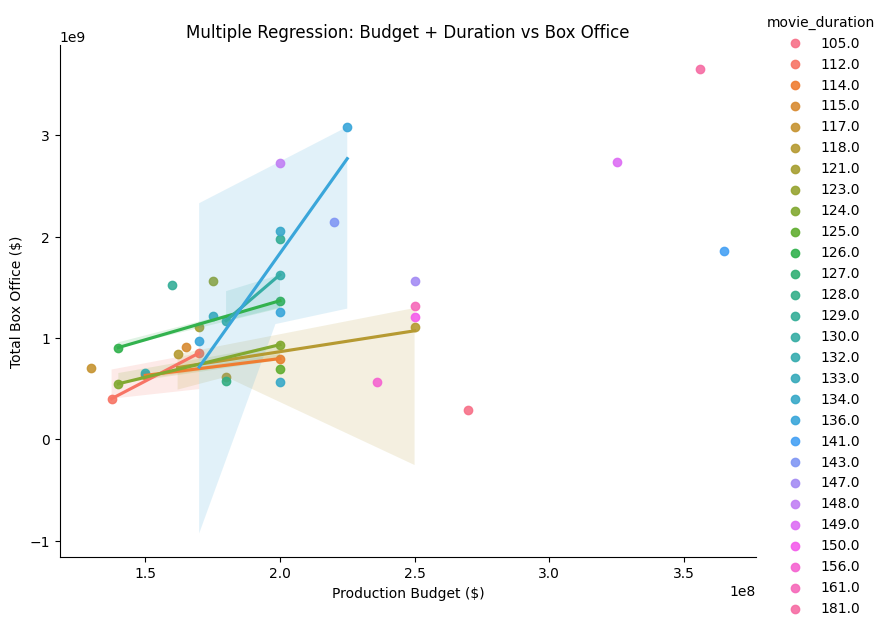

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(
    x="production_budget",
    y="total_box_office",
    hue="movie_duration",
    data=mar,
    height=6,
    aspect=1.3,
    scatter_kws={"alpha":0.9}
)

plt.title("Multiple Regression: Budget + Duration vs Box Office")
plt.xlabel("Production Budget ($)")
plt.ylabel("Total Box Office ($)")

plt.show()


In [18]:
import statsmodels.formula.api as smf

model = smf.ols("total_box_office ~ production_budget + movie_duration", data=mar).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:       total_box_office   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.437
Method:                 Least Squares   F-statistic:                     15.37
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           1.62e-05
Time:                        13:42:21   Log-Likelihood:                -819.50
No. Observations:                  38   AIC:                             1645.
Df Residuals:                      35   BIC:                             1650.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -2.666e+09    8.4e+0

From the regression results we get:
Intercept -   -2.666e+09
production_budget -  3.7960 
movie_duration   -    2.426e+07

So the predicted formula is:
Predicted Box Office = -2.666e+09 + ((3.796)(budget)) + ((2.426e+07)(duration))

In [31]:
def predict_box_office(budget, duration):
    intercept = -2.666e9
    coef_budget = 3.796
    coef_duration = 2.426e7
    
    return intercept + coef_budget * budget + coef_duration * duration

predict_box_office(250_000_000, 150)



1922000000.0

In [36]:
mar["predicted_box_office"] = (
    -2.666e9
    + 3.796 * mar["production_budget"]
    + 2.426e7 * mar["movie_duration"]
)
mar["predicted_box_office_frm"] = mar["predicted_box_office"].apply(lambda x: f"${x:,.2f}")
mar.head()


C:\Users\Invate\AppData\Local\Temp\ipykernel_8008\2414320687.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mar["predicted_box_office"] = (
C:\Users\Invate\AppData\Local\Temp\ipykernel_8008\2414320687.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mar["predicted_box_office_frm"] = mar["predicted_box_office"].apply(lambda x: f"${x:,.2f}")


,movie_title,mcu_phase,release_date,tomato_meter,audience_score,movie_duration,production_budget,opening_weekend,domestic_box_office,worldwide_box_office,total_box_office,total_box_office_fmt,predicted_box_office,predicted_box_office_frm
0,Iron Man,Phase 1,2008-05-02,94,91,126.0,140000000.0,102118668.0,319034126.0,585796247.0,904830373.0,"$904,830,373.00",9.222000e+08,"$922,200,000.00"
1,The Incredible Hulk,Phase 1,2008-06-13,67,70,112.0,137500000.0,55414050.0,134806913.0,265573859.0,400380772.0,"$400,380,772.00",5.730700e+08,"$573,070,000.00"
2,Iron Man 2,Phase 1,2010-05-07,72,71,124.0,200000000.0,128122480.0,312433331.0,621156389.0,933589720.0,"$933,589,720.00",1.101440e+09,"$1,101,440,000.00"
3,Thor,Phase 1,2011-05-06,77,76,114.0,150000000.0,65723338.0,181030624.0,449326618.0,630357242.0,"$630,357,242.00",6.690400e+08,"$669,040,000.00"
4,Captain America The First Avenger,Phase 1,2011-07-22,80,75,124.0,140000000.0,65058524.0,176654505.0,370569774.0,547224279.0,"$547,224,279.00",8.736800e+08,"$873,680,000.00"


C:\Users\Invate\AppData\Local\Temp\ipykernel_8008\193368410.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


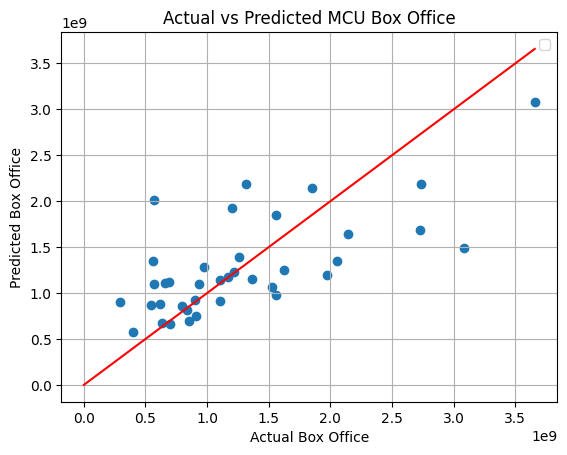

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(mar["total_box_office"], mar["predicted_box_office"])
plt.plot([0, mar["total_box_office"].max()], #x
         [0, mar["total_box_office"].max()], #y
         color="red")
plt.xlabel("Actual Box Office")
plt.ylabel("Predicted Box Office")
plt.title("Actual vs Predicted MCU Box Office")
plt.grid(True)
plt.show()
